Title: PSL_cluster_fut.ipynb

Purpose: Make a clustering of large scale weather patterns with 2015-2024 and 2K warming conditions

Author: Onno Nennecke on 03.06.2025 Modified: 201.03.2026

Input data: 

- PSL Anomaly Data
    - This file lies here: /climca/people/onennecke/model_output/psl_anomaly/not_bc/
- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

- LEE Tables: LEE_dat_14_fut.csv, LEE_dat_7_fut.csv, LEE_dat_fut.csv, LEE_dat_14_selection_fut.csv, LEE_dat_7_selection_fut.csv, LEE_vl_fut.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

Output data:

- kmeans scores: psl_kmeans_score_diff_k.csv
    - This file lies here: /home/onennecke/psl_clustering/psl_kmeans_score_diff_k.csv
- Kmeans score Plot: PSL_cluster_elbow_silhouette
    - This file lies here: /home/onennecke/Code/Figures/
- centroids and labels
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc.npz'
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc_2.npz


### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
import cftime
# import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [3]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc_fut/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 7GB
Dimensions:   (ESM_run: 192, time: 4550, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 36kB 2030-01-01 2030-01-02 ... 2054-12-31
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
Data variables:
    psl       (ESM_run, time, lat, lon) float32 7GB dask.array<chunksize=(1, 1820, 40, 50), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

In [7]:
psl = ts_datasets['psl']  # (ESM_run, time, lat, lon)

# Stack spatial dimensions
psl_flat = psl.stack(space=("lat", "lon"))

# Move to (samples, features)
X_new = psl_flat.transpose("ESM_run", "time", "space")

# Combine ESM_run + time into single sample dimension
X_new = X_new.stack(sample=("ESM_run", "time"))

# Convert to numpy
X_new_np = X_new.values

In [ ]:
n_samples_new

In [8]:
X_new_np.shape

(2000, 873600)

In [25]:
# data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
# labels = data['labels']
# centroids_reshaped = data['centroids_reshaped']

data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
centroids = data['centroids_reshaped']   # (5, 40, 50)

psl = ts_datasets['psl']   # (ESM_run, time, lat, lon)

print(psl.shape)
print(centroids.shape)

# stack lat/lon
psl_flat = psl.stack(space=("lat", "lon"))
# 2) Transpose so space is LAST
psl_flat = psl_flat.transpose("ESM_run", "time", "space")
print(psl_flat.shape)
# (192, 4550, 2000)

# 3) Stack sample dimension
X_new = psl_flat.stack(sample=("ESM_run", "time"))
# 4) Make sure sample is first
X_new_np = X_new.transpose("sample", "space")

print(X_new_np.shape)
# reshape centroids
centroids_flat = centroids.reshape(centroids.shape[0], -1)

print(centroids_flat.shape)

# X_new = psl_flat.stack(sample=("ESM_run", "time"))
# X_new_np = X_new.values   # (n_samples, 2000)

# print(X_new.shape)
# print(X_new_np.shape)


(192, 4550, 40, 50)
(5, 40, 50)
(192, 4550, 2000)
(873600, 2000)
(5, 2000)


In [26]:
from scipy.spatial.distance import cdist

distances = cdist(X_new_np, centroids_flat)
new_labels = np.argmin(distances, axis=1)

In [27]:


cluster_da = xr.DataArray(
    new_labels,
    coords={"sample": X_new.sample},
    dims=["sample"]
)

cluster_da = cluster_da.unstack("sample")

In [39]:
# True where ALL lat/lon values are NaN
all_nan_mask = psl.isnull().all(dim=("lat", "lon"))

cluster_da = cluster_da.where(~all_nan_mask)

# print("Number of empty maps:", all_nan_mask.sum().item())

In [40]:
cluster_da

<xarray.DataArray (ESM_run: 192, time: 4550)> Size: 7MB
dask.array<where, shape=(192, 4550), dtype=float64, chunksize=(1, 1820), chunktype=numpy.ndarray>
Coordinates:
  * ESM_run   (ESM_run) object 2kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i...
  * time      (time) datetime64[ns] 36kB 2030-01-01 2030-01-02 ... 2054-12-31
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'

(array([76714.,     0., 91062.,     0.,     0., 54145.,     0., 75872.,
            0., 51647.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

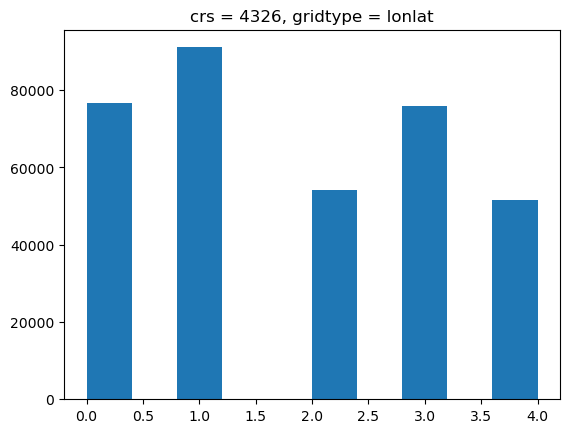

In [41]:
cluster_da.plot.hist()

### Check something probably delete

##### Look how the clusters are seasonaly distributed

In [42]:
# ────────────── 1) Recover time‐coordinates for each “flattened” sample ──────────────
n_ESM = ts_datasets.sizes['ESM_run']  # number of ESM runs
n_times = ts_datasets.sizes['time']    # number of time‐slices
time_coords = ts_datasets['time'].values      # shape = (n_times,), dtype=datetime64

times_repeated = np.repeat(time_coords, n_ESM)

len(times_repeated)

873600

In [43]:
# ────────────── 2) Recover ESM‐run coordinates for each “flattened” sample ──────────────
ESM_run = ts_datasets['ESM_run'].values
esm_run_coords = np.repeat(ESM_run, n_times)
esm_run_coords

array(['ACCESS-CM2_r1i1p1f1', 'ACCESS-CM2_r1i1p1f1',
       'ACCESS-CM2_r1i1p1f1', ..., 'UKESM1-0-LL_r8i1p1f2',
       'UKESM1-0-LL_r8i1p1f2', 'UKESM1-0-LL_r8i1p1f2'], dtype='<U23')

In [44]:
# ────────────── 2) Recover ESM‐run coordinates for each “flattened” sample ──────────────
ESMs = ts_datasets['ESM'].values
esm_coords = np.repeat(ESMs, n_times)
esm_coords

array(['ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', ..., 'UKESM1-0-LL',
       'UKESM1-0-LL', 'UKESM1-0-LL'], dtype='<U13')

In [45]:
len(esm_run_coords)
n_ESM

192

In [47]:
cluster_da

<xarray.DataArray (ESM_run: 192, time: 4550)> Size: 7MB
dask.array<where, shape=(192, 4550), dtype=float64, chunksize=(1, 1820), chunktype=numpy.ndarray>
Coordinates:
  * ESM_run   (ESM_run) object 2kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i...
  * time      (time) datetime64[ns] 36kB 2030-01-01 2030-01-02 ... 2054-12-31
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'

In [54]:
labels_fut = cluster_da.values.flatten()

In [60]:
labels_fut.shape

(873600,)

In [55]:
# Count non na values
non_na_count = np.count_nonzero(~np.isnan(labels_fut))
print(non_na_count)

349440


In [57]:
349440 / 192 / 10

182.0

In [48]:
data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
labels = data['labels']
labels.shape

(351260,)

In [51]:
351260 / 193 / 10

182.0

In [59]:
esm_run_coords.shape

(873600,)

In [61]:
# ────────────── 2) Build a small DataFrame with (time, cluster) ──────────────

df = pd.DataFrame({
    "time":    times_repeated,
    "cluster": labels_fut,
    "ESM_run": esm_run_coords,
    "ESM":     esm_coords
})
# df

In [65]:
df

,time,cluster,ESM_run,ESM
0,2030-01-01,NaN,ACCESS-CM2_r1i1p1f1,ACCESS-CM2
1,2030-01-01,NaN,ACCESS-CM2_r1i1p1f1,ACCESS-CM2
2,2030-01-01,NaN,ACCESS-CM2_r1i1p1f1,ACCESS-CM2
3,2030-01-01,NaN,ACCESS-CM2_r1i1p1f1,ACCESS-CM2
4,2030-01-01,NaN,ACCESS-CM2_r1i1p1f1,ACCESS-CM2
...,...,...,...,...
873595,2054-12-31,NaN,UKESM1-0-LL_r8i1p1f2,UKESM1-0-LL
873596,2054-12-31,NaN,UKESM1-0-LL_r8i1p1f2,UKESM1-0-LL
873597,2054-12-31,NaN,UKESM1-0-LL_r8i1p1f2,UKESM1-0-LL
873598,2054-12-31,NaN,UKESM1-0-LL_r8i1p1f2,UKESM1-0-LL


In [66]:
# Remove rows where cluster is NaN
df = df.dropna(subset=["cluster"])
df

,time,cluster,ESM_run,ESM
728,2030-01-04,1.0,ACCESS-CM2_r1i1p1f1,ACCESS-CM2
729,2030-01-04,1.0,ACCESS-CM2_r1i1p1f1,ACCESS-CM2
730,2030-01-04,1.0,ACCESS-CM2_r1i1p1f1,ACCESS-CM2
731,2030-01-04,1.0,ACCESS-CM2_r1i1p1f1,ACCESS-CM2
732,2030-01-04,1.0,ACCESS-CM2_r1i1p1f1,ACCESS-CM2
...,...,...,...,...
870865,2054-12-17,3.0,UKESM1-0-LL_r8i1p1f2,UKESM1-0-LL
870866,2054-12-17,2.0,UKESM1-0-LL_r8i1p1f2,UKESM1-0-LL
870867,2054-12-17,3.0,UKESM1-0-LL_r8i1p1f2,UKESM1-0-LL
870868,2054-12-17,0.0,UKESM1-0-LL_r8i1p1f2,UKESM1-0-LL


In [67]:
cluster_counts = df['cluster'].value_counts().sort_index()
total_counts = len(df)
cluster_probabilities = cluster_counts / total_counts
print("Cluster Occurrences:\n", cluster_counts)
print("\nCluster Occurrence Probabilities:\n", cluster_probabilities)

Cluster Occurrences:
 cluster
0.0    76714
1.0    91062
2.0    54145
3.0    75872
4.0    51647
Name: count, dtype: int64

Cluster Occurrence Probabilities:
 cluster
0.0    0.219534
1.0    0.260594
2.0    0.154948
3.0    0.217125
4.0    0.147799
Name: count, dtype: float64


--- 

In [68]:
# ────────────── 3) Map each date → its meteorological season ──────────────

def month_to_season(m):
    # Meteorological seasons in the northern hemisphere:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:  # 9,10,11
        return "SON"

# Extract month from each timestamp, then map to season:
df["month"]  = pd.DatetimeIndex(df["time"]).month
df["season"] = df["month"].map(month_to_season)
# df


/tmp/ipykernel_2501020/3464070617.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["month"]  = pd.DatetimeIndex(df["time"]).month
/tmp/ipykernel_2501020/3464070617.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["season"] = df["month"].map(month_to_season)


In [69]:
# ────────────── 4) Count how many samples of each cluster fall in each season ──────────────

# This gives you a table with index = cluster ID, columns = season, and counts = number of samples.
monthly_counts = (
    df
    .groupby(["cluster", "month"])
    .size()
    .unstack(fill_value=0)
)  
# e.g. monthly_counts.loc[2, "JJA"] is “how many cluster–2 days fall in summer (JJA).”

# If you want fractions instead of raw counts, you can do:
monthly_frac = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)
# Now each row sums to 1, so monthly_frac.loc[i, s] is the fraction of cluster i’s samples in season s.


In [70]:
monthly_frac
# Calculate the sum per month
monthly_sum = monthly_counts.sum(axis=0)
monthly_sum
# Oktober passt
# November passt
# Dezember passt
# Januar passt
# Februar passt


month
1     59756
2     52664
3     59450
10    60760
11    54850
12    61960
dtype: int64

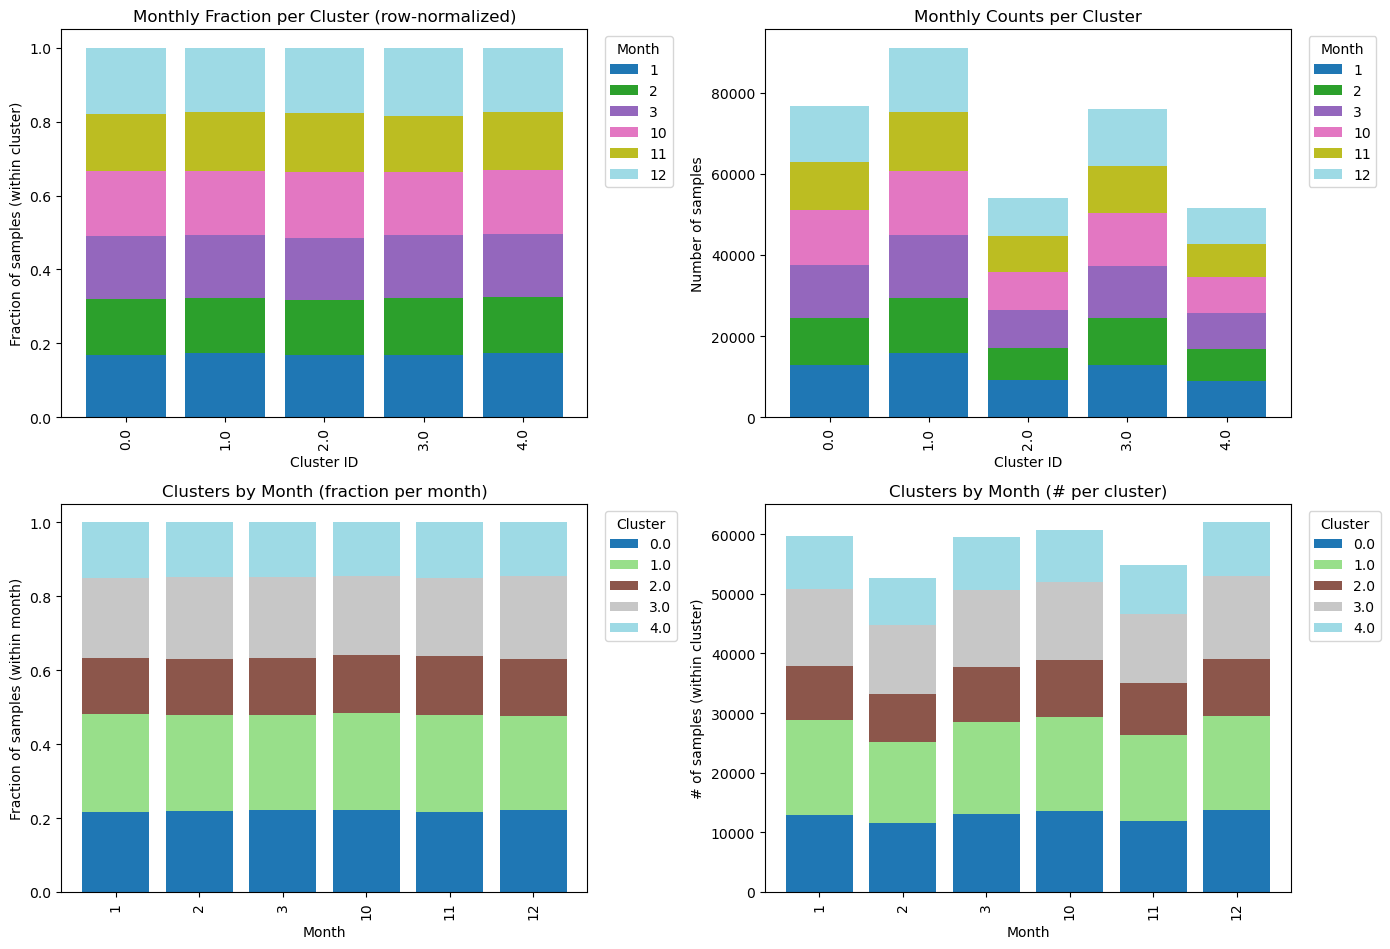

In [71]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# 1) Top‐Left: monthly_frac (clusters on x‐axis, months stacked)
monthly_frac.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="tab20",
    width=0.8
)
axes[0].set_xlabel("Cluster ID")
axes[0].set_ylabel("Fraction of samples (within cluster)")
axes[0].set_title("Monthly Fraction per Cluster (row‐normalized)")
axes[0].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 2) Top‐Right: monthly_counts (clusters on x‐axis, months stacked)
monthly_counts.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    colormap="tab20",
    width=0.8
)
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Number of samples")
axes[1].set_title("Monthly Counts per Cluster")
axes[1].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Right: monthly_frac_within_month.T (months on x‐axis, clusters stacked; fraction within month)
monthly_frac_within_month = monthly_counts.div(monthly_counts.sum(axis=0), axis=1)

monthly_frac_within_month.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[2],
    colormap="tab20",
    width=0.8
)
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Fraction of samples (within month)")
axes[2].set_title("Clusters by Month (fraction per month)")
axes[2].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Left: monthly_counts.T (months on x‐axis, clusters stacked; fraction within cluster)
monthly_counts.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[3],
    colormap="tab20",
    width=0.8
)
axes[3].set_xlabel("Month")
axes[3].set_ylabel("# of samples (within cluster)")
axes[3].set_title("Clusters by Month (# per cluster)")
axes[3].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")



# ────────────── D) Adjust layout ──────────────

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.suptitle("Seasonal/Monthly Distribution of Clusters", fontsize=16, y=0.99)
plt.show()

----

### Look at distribution for each ESM

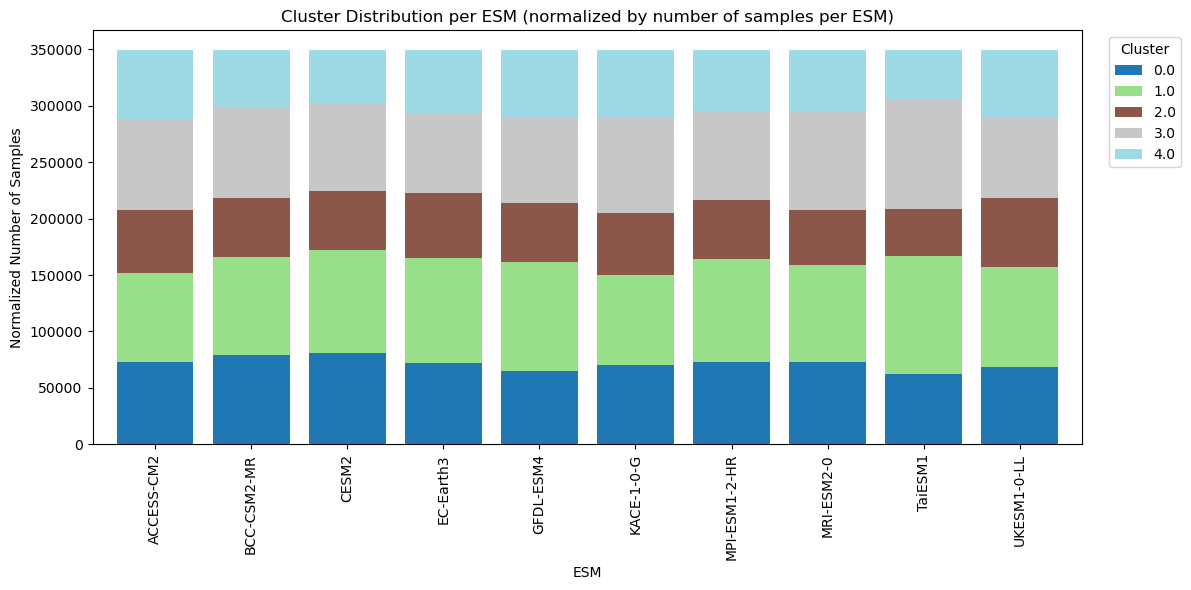

In [72]:
# Make one plot for all ESMs each represented by a stacked barplot normalize by number of samples per ESM
# Calculate the number of samples per ESM
samples_per_esm = df['ESM'].value_counts()
samples_per_esm = samples_per_esm / samples_per_esm.sum()

# Group by ESM and cluster, then count occurrences
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
esm_cluster_counts = esm_cluster_counts.div(samples_per_esm, axis=0)
esm_cluster_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20",
    width=0.8
)
plt.xlabel("ESM")
plt.ylabel("Normalized Number of Samples")
plt.title("Cluster Distribution per ESM (normalized by number of samples per ESM)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

----

In [74]:
# 1) Unpack sizes & coords
times   = ts_datasets.time           # (1820,)
runs    = ts_datasets.ESM_run        # (11,)
# print(times.shape, runs.shape)

# 2) Reshape labels → (time, ESM_run)
labels_da = xr.DataArray(
    labels_fut.reshape(len(runs), len(times)),
    dims    = ("ESM_run", "time"),
    coords  = {"ESM_run": runs, "time": times},
    name    = "cluster_id",
)
labels_da

<xarray.DataArray 'cluster_id' (ESM_run: 192, time: 4550)> Size: 7MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [ 2.,  2.,  0., ..., nan, nan, nan],
       [ 1.,  1.,  1., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan]])
Coordinates:
  * ESM_run  (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1p...
  * time     (time) datetime64[ns] 36kB 2030-01-01 2030-01-02 ... 2054-12-31

In [90]:
labels_da

<xarray.DataArray 'cluster_id' (ESM_run: 192, time: 4550)> Size: 7MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [ 2.,  2.,  0., ..., nan, nan, nan],
       [ 1.,  1.,  1., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan]])
Coordinates:
  * ESM_run  (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1p...
  * time     (time) datetime64[ns] 36kB 2030-01-01 2030-01-02 ... 2054-12-31

In [92]:
encoding = {}

all_vars = {**labels_da.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"U{maxlen}"}
encoding

{'ESM_run': {'dtype': 'U23'}}

In [95]:
# Save labels_da
labels_da.to_netcdf('/home/onennecke/psl_clustering/cluster_labels_fut.nc', encoding=encoding)

In [84]:
labels_da.isel(ESM_run=-2, time=1).values

array(1.)

In [82]:
vmin
vmax

np.float32(67.33102)

/tmp/ipykernel_2501020/1408133032.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


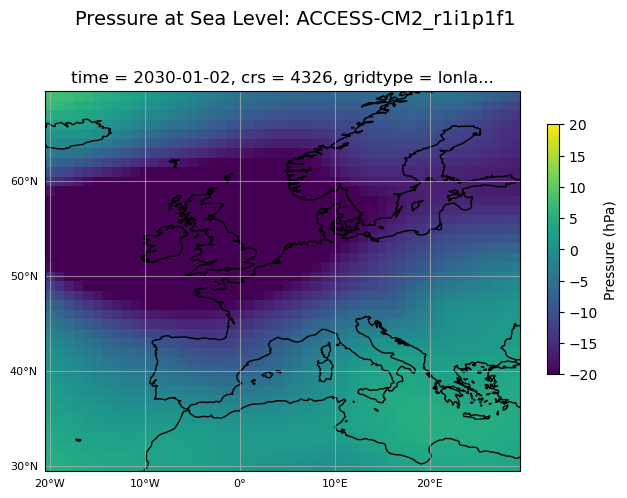

In [86]:
# Select a specific ESM run and one time step
tst = ts_datasets.isel(ESM_run=-1, time=1)


# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = -20 # np.nanmin(ts_datasets['psl'] / 100.0)
vmax = 20 #np.nanmax(ts_datasets['psl'] / 100.0)
# Compute vmin/vmax as Python floats
# vmin_da = tst['psl'].min() / 100
# vmax_da = tst['psl'].max() / 100

# cf = ax.contourf(lons, lats,(cluster_means[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
# cmap_used = cf.cmap  # capture the colormap for later

# # Force evaluation and extract a scalar
# vmin = float(vmin_da.compute())
# vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    # cmap=cmap_used,
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle('Pressure at Sea Level: ACCESS-CM2_r1i1p1f1', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


### Select relevant timesteps

In [41]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')

In [42]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd')]

# Rename ESM_run for ERA5_hist_week to ERA5_hist
LEE_dat['ESM_run'] = LEE_dat['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_7['ESM_run'] = LEE_7['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_14['ESM_run'] = LEE_14['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_vl['ESM_run'] = LEE_vl['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})

# Kick every date in April
LEE_dat = LEE_dat[LEE_dat['date_start'].str[5:7] != '04']
LEE_7 = LEE_7[LEE_7['date_start'].str[5:7] != '04']
LEE_14 = LEE_14[LEE_14['date_start'].str[5:7] != '04']
LEE_vl = LEE_vl[LEE_vl['date_start'].str[5:7] != '04']


In [43]:
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1422.938372,1422.938372,0.0,1422.938372,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1437.874790,1437.874790,0.0,1437.874790,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1479.213802,1479.213802,0.0,1479.213802,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1469.434683,1469.434683,0.0,1469.434683,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1484.162541,1484.162541,0.0,1484.162541,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18510,2024-11-11,2024-11-11,2024-11-11,3599,3599,3599,1,1421.550574,1421.550574,0.0,1421.550574,18511,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,315
18511,2024-11-14,2024-11-14,2024-11-14,3602,3602,3602,1,1412.749315,1412.749315,0.0,1412.749315,18512,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,318
18512,2024-11-16,2024-11-16,2024-11-16,3604,3604,3604,1,1468.689654,1468.689654,0.0,1468.689654,18513,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,320
18513,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1470.531086,1470.531086,0.0,1470.531086,18514,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,354


In [44]:

count = 0
for esm in LEE_7['ESM'].unique():
    esm_entries = LEE_7[LEE_7['ESM'] == esm]
    count += len(esm_entries)
    print(esm, len(esm_entries))
    # if len(esm_entries) > 0:
    #     print(esm_entries['time'].values)
    #     print(esm_entries['cluster'].values)
    #     print('-------------------')
print('Total number of entries:', count)

ACCESS-CM2 40
BCC-CSM2-MR 17
CESM2 22
EC-Earth3 470
ERA5_week 10
GFDL-ESM4 10
KACE-1-0-G 21
MPI-ESM1-2-HR 154
MRI-ESM2-0 45
TaiESM1 7
UKESM1-0-LL 337
Total number of entries: 1133


In [45]:
# 3) Lookup per‐event cluster
#    assumes `LEE_1_subset` has cols ["date_start","ESM_run"]
LEE_dat["cluster_at_start"] = [
    labels_da.sel(time=dt, ESM_run=run).item()
    for dt, run in zip(LEE_dat.date_start, LEE_dat.ESM_run)
]
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,cluster_at_start
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1422.938372,1422.938372,0.0,1422.938372,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5,0
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1437.874790,1437.874790,0.0,1437.874790,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7,4
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1479.213802,1479.213802,0.0,1479.213802,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8,4
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1469.434683,1469.434683,0.0,1469.434683,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18,0
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1484.162541,1484.162541,0.0,1484.162541,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18510,2024-11-11,2024-11-11,2024-11-11,3599,3599,3599,1,1421.550574,1421.550574,0.0,1421.550574,18511,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,315,4
18511,2024-11-14,2024-11-14,2024-11-14,3602,3602,3602,1,1412.749315,1412.749315,0.0,1412.749315,18512,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,318,4
18512,2024-11-16,2024-11-16,2024-11-16,3604,3604,3604,1,1468.689654,1468.689654,0.0,1468.689654,18513,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,320,4
18513,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1470.531086,1470.531086,0.0,1470.531086,18514,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,354,4


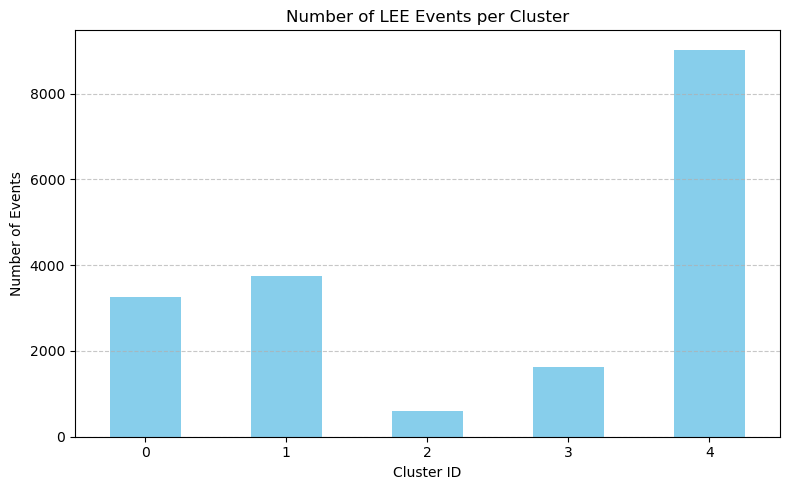

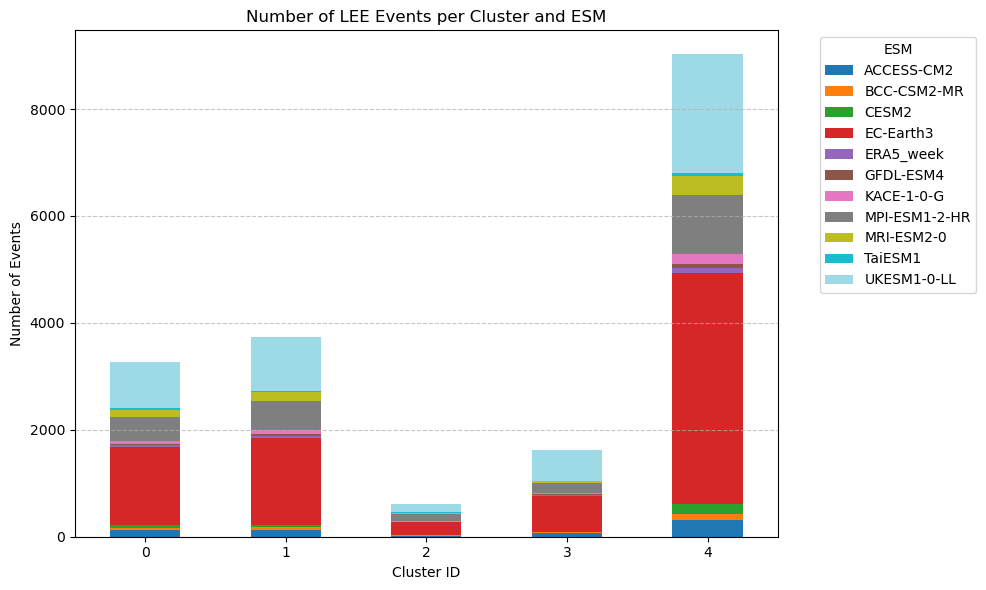

In [46]:
# Make a bar plot of the number of events per cluster
cluster_counts = LEE_dat['cluster_at_start'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per ESM
cluster_esm_counts = LEE_dat.groupby(['cluster_at_start', 'ESM']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
cluster_esm_counts.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster and ESM")
plt.xticks(rotation=0)
plt.legend(title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per season

In [36]:
# Select one exemplary entry from LEE_1 for each ESM values
def select_exemplary_entries(LEE_df, ESMs):
    exemplary_entries = []
    for esm in ESMs:
        esm_entries = LEE_df[LEE_df['ESM'] == esm]
        if not esm_entries.empty:
            exemplary_entry = esm_entries.iloc[0]  # Select the first entry for each ESM
            exemplary_entries.append(exemplary_entry)
    return pd.DataFrame(exemplary_entries)
# LEE_1_subset = select_exemplary_entries(LEE_1, unique_esms)
# Select one the first run of each ESM from LEE_1
def select_first_run_entries(LEE_df, ESMs):
    first_run_entries = LEE_df.iloc[0:0].copy()

    for esm in ESMs:
        esm_entries = LEE_df[LEE_df['ESM'] == esm]
        if not esm_entries.empty:
            first_run = esm_entries['ESM_run'].unique()[0]
            first_run_entry = esm_entries[esm_entries['ESM_run'] == first_run]
            first_run_entries = pd.concat([first_run_entries, first_run_entry], ignore_index=True)
    return first_run_entries

# LEE_1_subset = select_first_run_entries(LEE_1, unique_esms)
LEE_1_subset = LEE_1.copy()
# LEE_1_subset = LEE_1[0:10]
# LEE_1_subset

In [43]:
LEE_1_subset = LEE_1_subset[~LEE_1_subset['ESM'].isin(['ERA5_wwd', 'ERA5_week'])]
LEE_1_subset['ESM'].unique()

array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1',
       'UKESM1-0-LL'], dtype=object)

In [44]:
# 3) Lookup per‐event cluster
#    assumes `LEE_1_subset` has cols ["date_start","ESM_run"]
LEE_1_subset["cluster_at_start"] = [
    labels_da.sel(time=dt, ESM_run=run).item()
    for dt, run in zip(LEE_1_subset.date_start, LEE_1_subset.ESM_run)
]
LEE_1_subset

/tmp/ipykernel_4141038/3797269934.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LEE_1_subset["cluster_at_start"] = [


,date_start,date_end,date_peak,date_start_old,date_end_old,date_peak_old,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter,cluster_at_start
0,2015-01-18 12:00:00,2015-01-18 12:00:00,2015-01-18 12:00:00.000000000,1421582400000000000,1421582400000000000,1421582400000000000,17,17,17,1,1373.585419,1373.585419,0.000000,1373.585419,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2014,110,0
1,2015-10-21 12:00:00,2015-10-21 12:00:00,2015-10-21 12:00:00.000000000,1445428800000000000,1445428800000000000,1445428800000000000,110,110,110,1,1378.601098,1378.601098,0.000000,1378.601098,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,21,2
2,2015-11-04 12:00:00,2015-11-05 12:00:00,2015-11-04 12:00:00.000000000,1446638400000000000,1446724800000000000,1446638400000000000,124,125,124,2,1404.935534,1401.253278,3.682256,2802.506556,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,35,2
3,2015-12-16 12:00:00,2015-12-17 12:00:00,2015-12-16 12:00:00.000000000,1450267200000000000,1450353600000000000,1450267200000000000,166,167,166,2,1454.631376,1415.495103,39.136273,2830.990205,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,77,2
4,2016-12-12 12:00:00,2016-12-12 12:00:00,2016-12-12 12:00:00.000000000,1481544000000000000,1481544000000000000,1481544000000000000,344,344,344,1,1428.634773,1428.634773,0.000000,1428.634773,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5321,2023-12-21 12:00:00,2023-12-21 12:00:00,2023-12-21 12:00:00.000000000,2023-12-22 12:00:00,2023-12-22 12:00:00,2023-12-22 12:00:00,1627,1627,1627,1,1378.105975,1378.105975,0.000000,1378.105975,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,82,1
5322,2023-12-23 12:00:00,2023-12-23 12:00:00,2023-12-23 12:00:00.000000000,2023-12-24 12:00:00,2023-12-24 12:00:00,2023-12-24 12:00:00,1629,1629,1629,1,1409.127953,1409.127953,0.000000,1409.127953,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,84,1
5323,2024-01-25 12:00:00,2024-01-25 12:00:00,2024-01-25 12:00:00.000000000,2024-01-27 12:00:00,2024-01-27 12:00:00,2024-01-27 12:00:00,1662,1662,1662,1,1390.731921,1390.731921,0.000000,1390.731921,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,117,1
5324,2024-11-14 12:00:00,2024-11-14 12:00:00,2024-11-14 12:00:00.000000000,2024-11-15 12:00:00,2024-11-15 12:00:00,2024-11-15 12:00:00,1772,1772,1772,1,1399.713515,1399.713515,0.000000,1399.713515,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,45,2


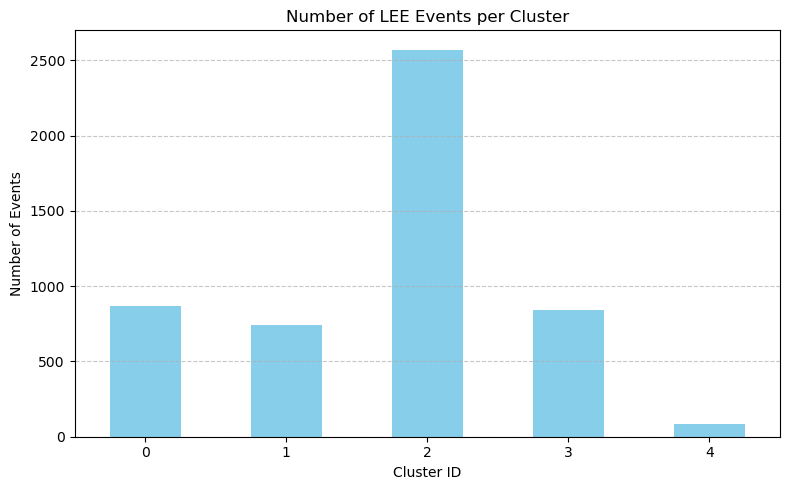

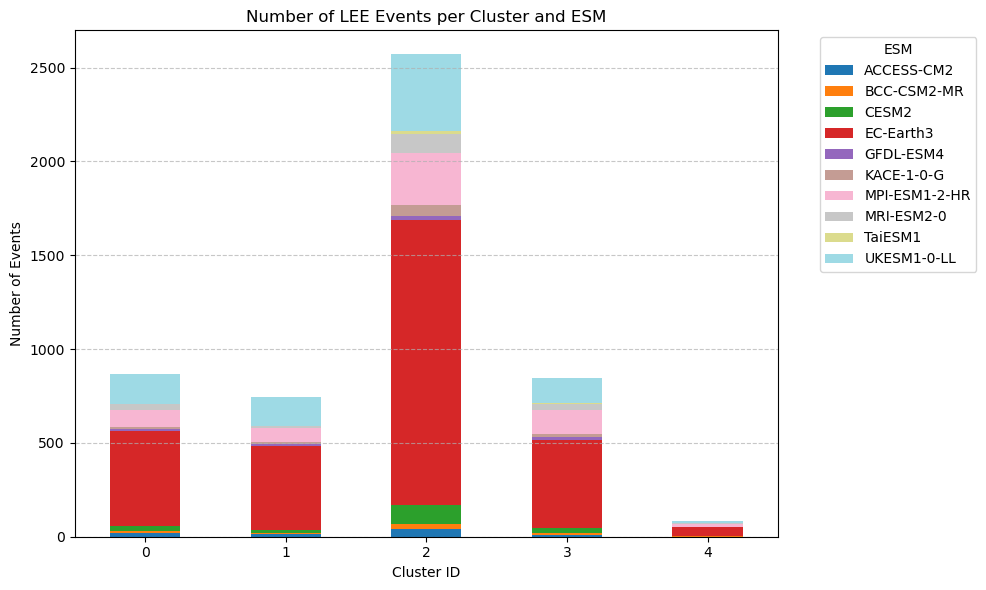

In [45]:
# Make a bar plot of the number of events per cluster
cluster_counts = LEE_1_subset['cluster_at_start'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per ESM
cluster_esm_counts = LEE_1_subset.groupby(['cluster_at_start', 'ESM']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
cluster_esm_counts.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster and ESM")
plt.xticks(rotation=0)
plt.legend(title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per season

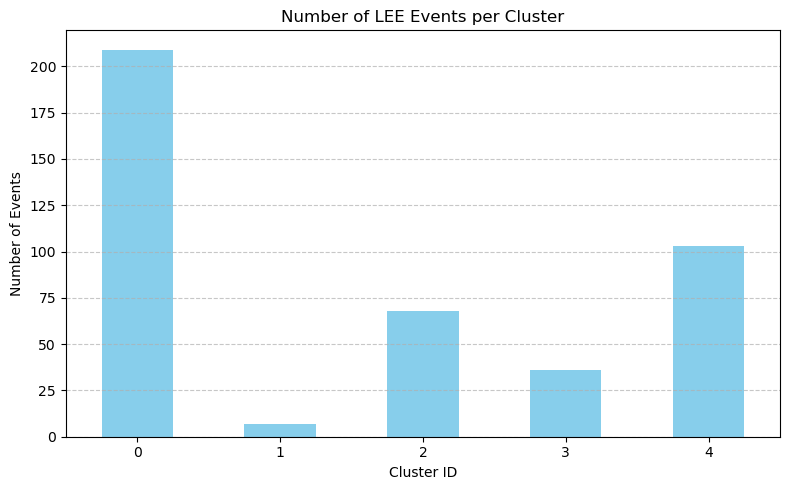

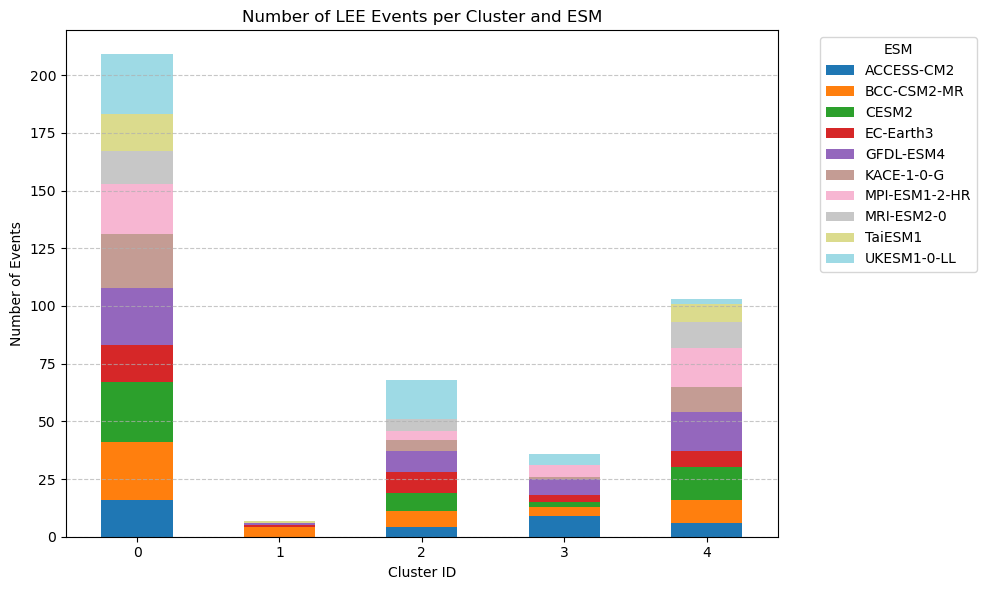

In [142]:
# Make a bar plot of the number of events per cluster
cluster_counts = LEE_1_subset['cluster_at_start'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per ESM
cluster_esm_counts = LEE_1_subset.groupby(['cluster_at_start', 'ESM']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
cluster_esm_counts.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster and ESM")
plt.xticks(rotation=0)
plt.legend(title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per season

In [ ]:
ts = 9

/tmp/ipykernel_4079217/1653708652.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


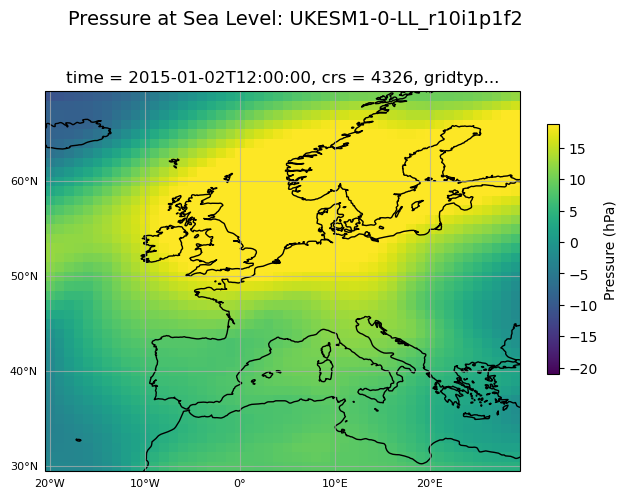

In [ ]:
# Select a specific ESM run and one time step
tst = ts_datasets.sel(ESM_run=LEE_1_subset['ESM_run'].iloc[ts], time=LEE_1_subset['date_start'].iloc[ts])

# Compute vmin/vmax as Python floats
# vmin_da = tst['psl'].min() / 100
# vmax_da = tst['psl'].max() / 100

# # Force evaluation and extract a scalar
# vmin = float(vmin_da.compute())
# vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap_used,
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle(f'Pressure at Sea Level: {LEE_1_subset['ESM_run'].iloc[ts]}', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


----

#### With PCA und scaling
Seems to have lower silhouette scores --> Worse

In [105]:
# 2.1 Scale (standardize) so each “feature” has zero mean & unit variance
scaler = StandardScaler()
X = scaler.fit_transform(arr_flat)
# 2.2 PCA to reduce dimensionality
pca = PCA(n_components=0.90, svd_solver='full')  # keep 90% variance
X_pca = pca.fit_transform(X)  # shape: (n_times, n_eofs)
X_pca
# 3. Run KMeans 
kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
kmeans.fit(X_pca)  # fit in EOF space
# 4. Extract labels & centroids (in EOF space)
labels = kmeans.labels_            # array length = n_times
centroids_pca = kmeans.cluster_centers_  # shape (4, n_eofs)

# 4.1 Convert centroids back to original space
centroids = pca.inverse_transform(centroids_pca) # back to scaled‐PSL
# 4.2 unscale the centroids
centroids_unscaled = scaler.inverse_transform(centroids) # back to anomaly space

# 5. Reshape centroids to lat/lon grid
centroids_reshaped = centroids_unscaled.reshape(k, n_lat, n_lon)  # shape (4, n_lat, n_lon)

score = silhouette_score(X_pca, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.15489839


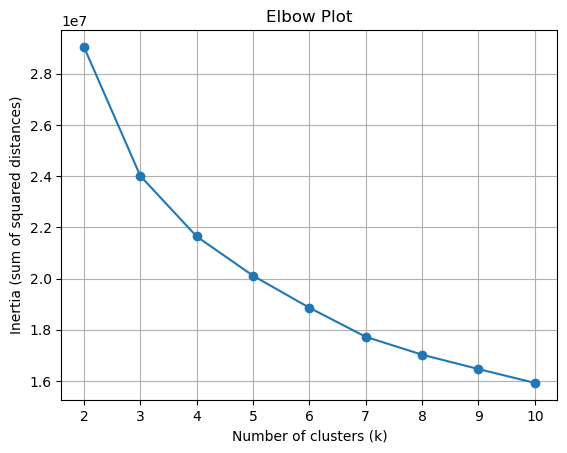

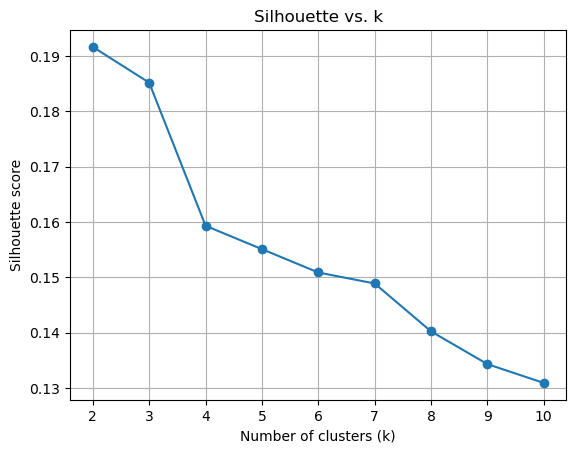

In [ ]:
# ----------------------------------------------------------------------
# 1) Elbow plot + Silhouette‐score vs. k
# ----------------------------------------------------------------------

# Choose which k‐values to test:
k_range = range(2, 11)  # e.g. test k = 2, 3, …, 10

inertias = []
silhouettes = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, n_init=20, random_state=1)
    labels_k = km.fit_predict(X_pca)      # cluster in EOF‐space
    inertias.append(km.inertia_)          # sum of squared distances to centroids

    # Silhouette: only valid if k_test < n_samples
    silh = silhouette_score(X_pca, labels_k)
    silhouettes.append(silh)

# Plot inertia (elbow)
plt.figure()
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Plot")
plt.grid(True)
plt.show()

# Plot silhouette score
plt.figure()
plt.plot(list(k_range), silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs. k")
plt.grid(True)
plt.show()


In [107]:
# ----------------------------------------------------------------------
# 2) Compute & Plot Composite (Mean) PSL Patterns for each cluster
# ----------------------------------------------------------------------

# Suppose we have chosen k_opt clusters:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

# Fit in EOF‐space and get labels
labels = kmeans.fit_predict(X_pca)      # length = n_samples = n_times*n_ESM

# Now, arr_flat has shape (n_samples, n_lat*n_lon).  Each row = one (time, ESM) flattened.
# We want to compute, for i = 0..k_opt-1:
#   mean_flat_i = mean over all samples whose label == i
#   then reshape mean_flat_i → (n_lat, n_lon)

cluster_means = np.zeros((k_opt, n_lat, n_lon))

for i in range(k_opt):
    idx_i = np.where(labels == i)[0]             # all sample‐indices in cluster i
    mean_flat_i = np.mean(arr_flat[idx_i, :], axis=0)  
    cluster_means[i, :, :] = mean_flat_i.reshape(n_lat, n_lon)

# Now cluster_means[i] is the composite PSL field (still in whatever units arr_flat had).
# If arr_flat was “raw PSL,” then these are raw composites.  If arr_flat was “anomalies,”
# add back your climatology if you want absolute values.  But the plotting procedure is the same.


/tmp/ipykernel_88847/1150397827.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar


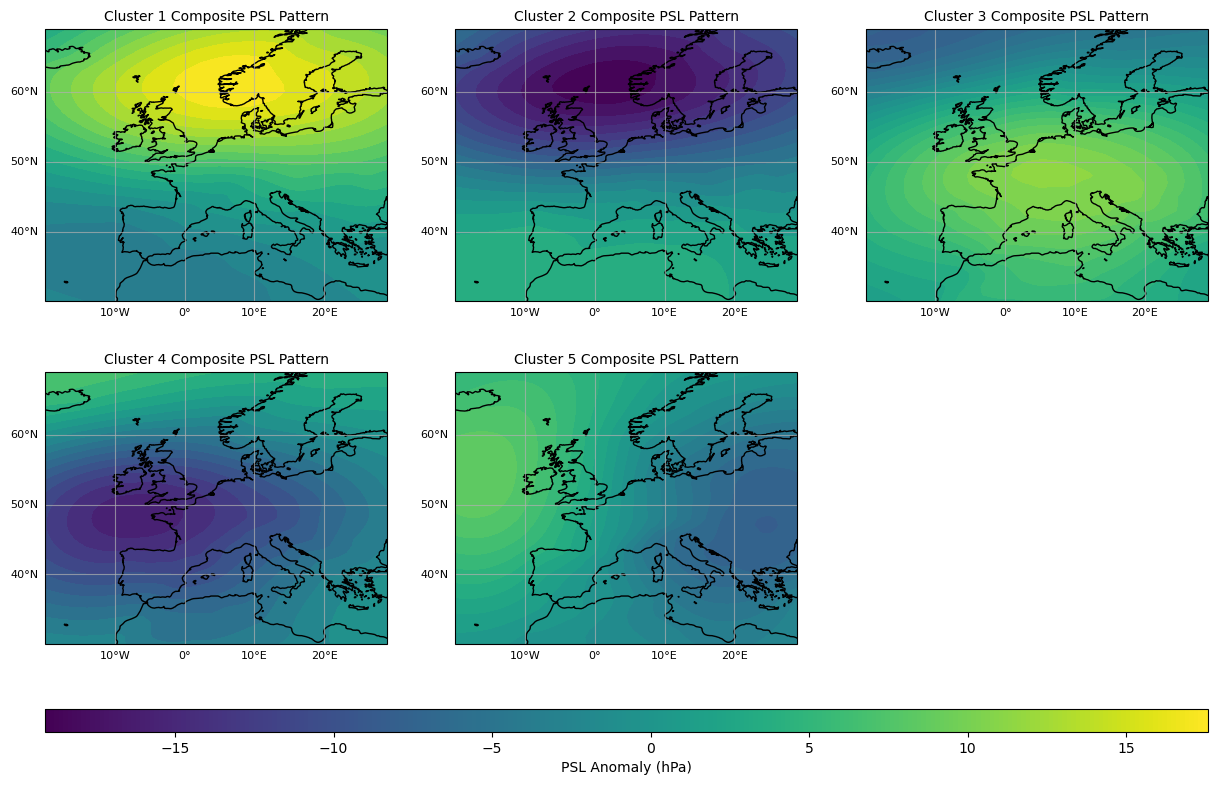

In [ ]:


# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(cluster_means / 100.0)
vmax = np.nanmax(cluster_means / 100.0)

# 2) Decide on subplot grid
ncols = 3
nrows = int(np.ceil(k_opt / ncols))

# 3) Create figure + GridSpec (last row for cbar)
fig = plt.figure(figsize=(5 * ncols, 4 * (nrows + 0.3)))
gs = GridSpec(nrows + 1, ncols,
              height_ratios=[1] * nrows + [0.08],
              hspace=0.3, wspace=0.2)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(k_opt):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())

    # Plot with fixed vmin/vmax
    cf = ax.contourf(lons, lats,(cluster_means[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    cmap_used = cf.cmap  # capture the colormap for later

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f"Cluster {i + 1} Composite PSL Pattern", fontsize=10)

# 5) Hide any “extra” empty axes if k_opt < nrows*ncols
for j in range(k_opt, nrows * ncols):
    row = j // ncols
    col = j % ncols
    fig.add_subplot(gs[row, col]).axis("off")

# 6) Create a ScalarMappable just for the colorbar, using the same colormap/norm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])  # no actual data needed, just for the colorbar

# 7) Place the horizontal colorbar in the final GridSpec row, spanning all columns
cax = fig.add_subplot(gs[nrows, :])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", pad=0.02)
cbar.set_label('PSL Anomaly (hPa)' if arr_flat.dtype != 'bool' else '', fontsize=10)

# 8) Tweak layout so maps and cbar don’t overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar
plt.show()


________

#### Without PCA and scaling
Takes quite long and has higher elbow and lower silhouette score --> overall worse

Cluster look the same

In [ ]:
# 2.1 Without standardization
X = arr_flat
# 2.2 Without PCA
# 3. Run KMeans 
kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
kmeans.fit(X)
# 4. Extract labels & centroids (in EOF space)
labels = kmeans.labels_            # array length = n_times
centroids = kmeans.cluster_centers_  # shape (4, n_eofs)

# 5. Reshape centroids to lat/lon grid
centroids = centroids.reshape(k, n_lat, n_lon)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)


Silhouette Score: 0.16087487


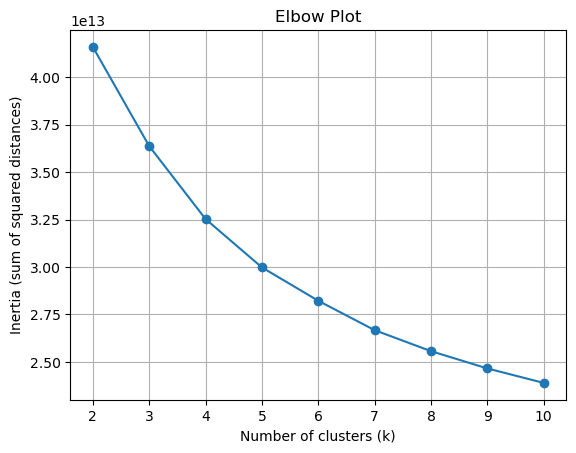

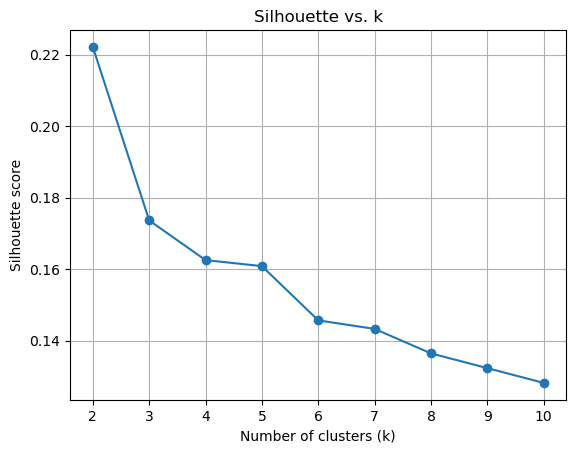

In [ ]:
# ----------------------------------------------------------------------
# 1) Elbow plot + Silhouette‐score vs. k
# ----------------------------------------------------------------------

# Choose which k‐values to test:
k_range = range(2, 11)  # e.g. test k = 2, 3, …, 10

inertias = []
silhouettes = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, n_init=30, random_state=2)
    labels_k = km.fit_predict(X)      # cluster in EOF‐space
    inertias.append(km.inertia_)          # sum of squared distances to centroids

    # Silhouette: only valid if k_test < n_samples
    silh = silhouette_score(X, labels_k)
    silhouettes.append(silh)

# Plot inertia (elbow)
plt.figure()
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Plot")
plt.grid(True)
plt.show()

# Plot silhouette score
plt.figure()
plt.plot(list(k_range), silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs. k")
plt.grid(True)
plt.show()

In [ ]:
# ----------------------------------------------------------------------
# 2) Compute & Plot Composite (Mean) PSL Patterns for each cluster
# ----------------------------------------------------------------------

# Suppose we have chosen k_opt clusters:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

# Fit in EOF‐space and get labels
labels = kmeans.fit_predict(X)      # length = n_samples = n_times*n_ESM

# Now, arr_flat has shape (n_samples, n_lat*n_lon).  Each row = one (time, ESM) flattened.
# We want to compute, for i = 0..k_opt-1:
#   mean_flat_i = mean over all samples whose label == i
#   then reshape mean_flat_i → (n_lat, n_lon)

cluster_means = np.zeros((k_opt, n_lat, n_lon))

for i in range(k_opt):
    idx_i = np.where(labels == i)[0]             # all sample‐indices in cluster i
    mean_flat_i = np.mean(arr_flat[idx_i, :], axis=0)  
    cluster_means[i, :, :] = mean_flat_i.reshape(n_lat, n_lon)

# Now cluster_means[i] is the composite PSL field (still in whatever units arr_flat had).
# If arr_flat was “raw PSL,” then these are raw composites.  If arr_flat was “anomalies,”
# add back your climatology if you want absolute values.  But the plotting procedure is the same.


/tmp/ipykernel_88847/191963972.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar


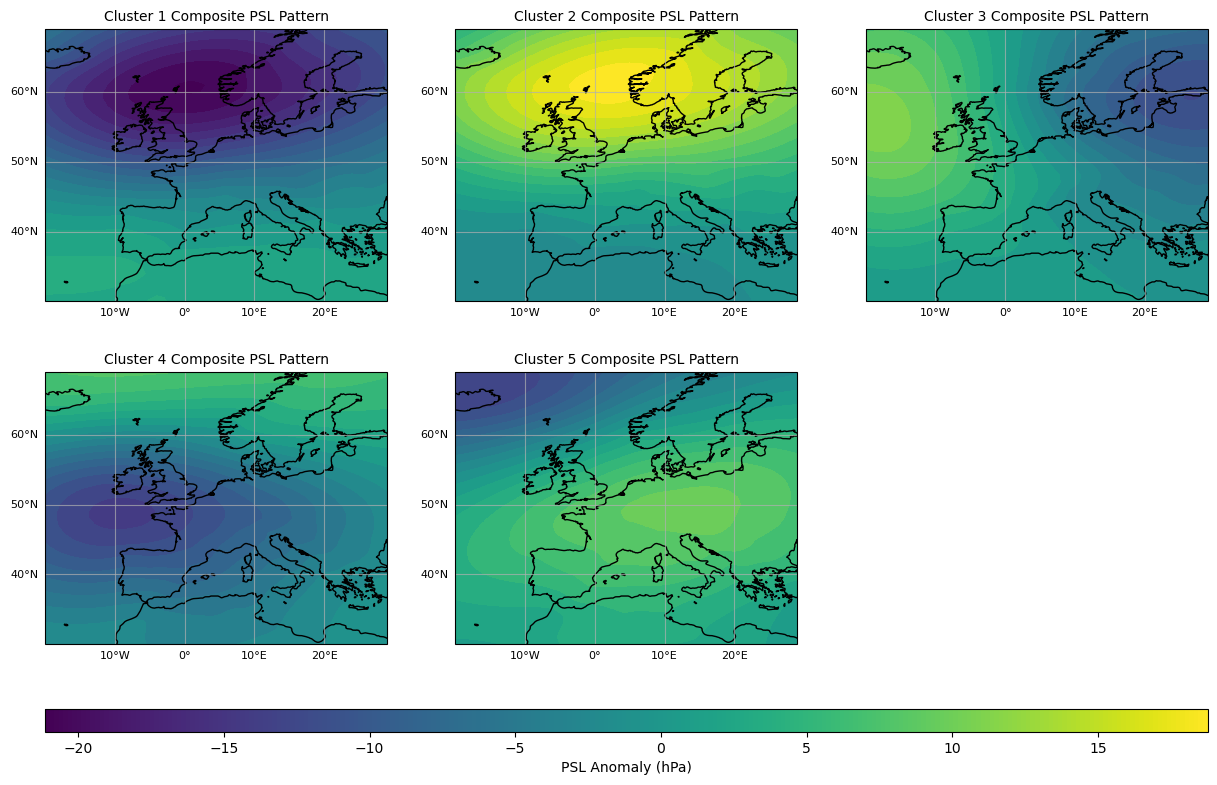

In [ ]:
# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(cluster_means / 100.0)
vmax = np.nanmax(cluster_means / 100.0)

# 2) Decide on subplot grid
ncols = 3
nrows = int(np.ceil(k_opt / ncols))

# 3) Create figure + GridSpec (last row for cbar)
fig = plt.figure(figsize=(5 * ncols, 4 * (nrows + 0.3)))
gs = GridSpec(nrows + 1, ncols,
              height_ratios=[1] * nrows + [0.08],
              hspace=0.3, wspace=0.2)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(k_opt):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())

    # Plot with fixed vmin/vmax
    cf = ax.contourf(lons, lats,(cluster_means[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    cmap_used = cf.cmap  # capture the colormap for later

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f"Cluster {i + 1} Composite PSL Pattern", fontsize=10)

# 5) Hide any “extra” empty axes if k_opt < nrows*ncols
for j in range(k_opt, nrows * ncols):
    row = j // ncols
    col = j % ncols
    fig.add_subplot(gs[row, col]).axis("off")

# 6) Create a ScalarMappable just for the colorbar, using the same colormap/norm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])  # no actual data needed, just for the colorbar

# 7) Place the horizontal colorbar in the final GridSpec row, spanning all columns
cax = fig.add_subplot(gs[nrows, :])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", pad=0.02)
cbar.set_label('PSL Anomaly (hPa)' if arr_flat.dtype != 'bool' else '', fontsize=10)

# 8) Tweak layout so maps and cbar don’t overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar
plt.show()
